In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.differentiate import derivative

In [ ]:
# data
m = np.array([-1, 2]).reshape(2, 1)
b = np.array([1, 1]).reshape(2, 1)
X = np.array([[1, 3], [4, 10]])
Y = np.array([5, 6]).reshape(2, 1)

In [ ]:
def f(X, m, b):
  return np.dot(X, m) + b

In [ ]:
def mse(y_true, X, m, b):
  return np.mean((y_true - f(X, m, b)) ** 2)

In [ ]:
def compute_derivative(equation, at_value):
    result = derivative(equation, at_value)
    return result.df

In [ ]:
def calculate_m_new(y_true, X, m, b, learning_rate):
    m_new = m.astype(float)
    for i in range(len(m)):
        # Define MSE as a function of m[i] alone
        def mse_wrt_mi(mi_val):
            mi_val = np.asarray(mi_val)
            if mi_val.ndim == 0:  # scalar case
                m_temp = m.astype(float)
                m_temp[i, 0] = mi_val.item()
                return np.mean((y_true - f(X, m_temp, b)) ** 2)
            else:  # array case
                results = []
                for val in mi_val.flat:
                    m_temp = m.astype(float)
                    m_temp[i, 0] = val
                    results.append(np.mean((y_true - f(X, m_temp, b)) ** 2))
                return np.array(results).reshape(mi_val.shape)

        # Use SciPy to compute the derivative at current m[i]
        grad = compute_derivative(mse_wrt_mi, at_value=float(m[i, 0]))
        m_new[i, 0] = m[i, 0] - learning_rate * grad
    return m_new


In [ ]:
def calculate_b_new(y_true, X, m, b, learning_rate):
    # MSE as a function of a single scalar offset added uniformly to all b elements,
    def mse_wrt_b_offset(delta):
        delta = np.asarray(delta)
        if delta.ndim == 0:
            return np.mean((y_true - f(X, m, b + delta.item())) ** 2)
        else:
            results = []
            for val in delta.flat:
                results.append(np.mean((y_true - f(X, m, b + val)) ** 2))
            return np.array(results).reshape(delta.shape)

    grad = compute_derivative(mse_wrt_b_offset, at_value=0.0)
    return b - learning_rate * grad

In [ ]:
learning_rate = 0.01
num_iterations = 1467

m_history = []
b_history = []
error_history = []

for i in range(num_iterations):
    error_history.append(mse(Y, X, m, b))
    m_history.append(m.flatten().copy())
    b_history.append(b.flatten().copy())
    m_new = calculate_m_new(Y, X, m, b, learning_rate)
    b_new = calculate_b_new(Y, X, m, b, learning_rate)
    m = m_new
    b = b_new


In [ ]:
y_predict = f(X, m, b)
print(f"Final m:{m}")
print(f"Final b:{b}")
print(f"Final MSE: {mse(Y, X, m, b):.6f}")
print(f"Y Predict:{y_predict}")
print(f"M history: {m_history}")
print(f"B history: {b_history}")
print(f"Error history: {error_history}")

Final m:[[-2.17875705]
 [ 1.09769303]]
Final b:[[3.77218923]
 [3.77218923]]
Final MSE: 0.007021
Y Predict:[[4.88651126]
 [6.0340913 ]]
M history: [array([-1,  2]), array([-1.45,  0.87]), array([-1.3316,  1.1808]), array([-1.369562,  1.095182]), array([-1.36447672,  1.11863408]), array([-1.37120931,  1.11207737]), array([-1.37466443,  1.11377772]), array([-1.3789955 ,  1.11320674]), array([-1.38305988,  1.11326119]), array([-1.38717208,  1.11314406]), array([-1.3912457 ,  1.11307464]), array([-1.39530462,  1.11299259]), array([-1.3993424,  1.1129145]), array([-1.40336093,  1.11283581]), array([-1.40735982,  1.11275777]), array([-1.41133929,  1.11268004]), array([-1.41529941,  1.11260271]), array([-1.41924027,  1.11252574]), array([-1.42316197,  1.11244916]), array([-1.42706461,  1.11237294]), array([-1.43094827,  1.1122971 ]), array([-1.43481304,  1.11222162]), array([-1.43865902,  1.11214651]), array([-1.44248631,  1.11207177]), array([-1.44629498,  1.11199739]), array([-1.45008514,  1

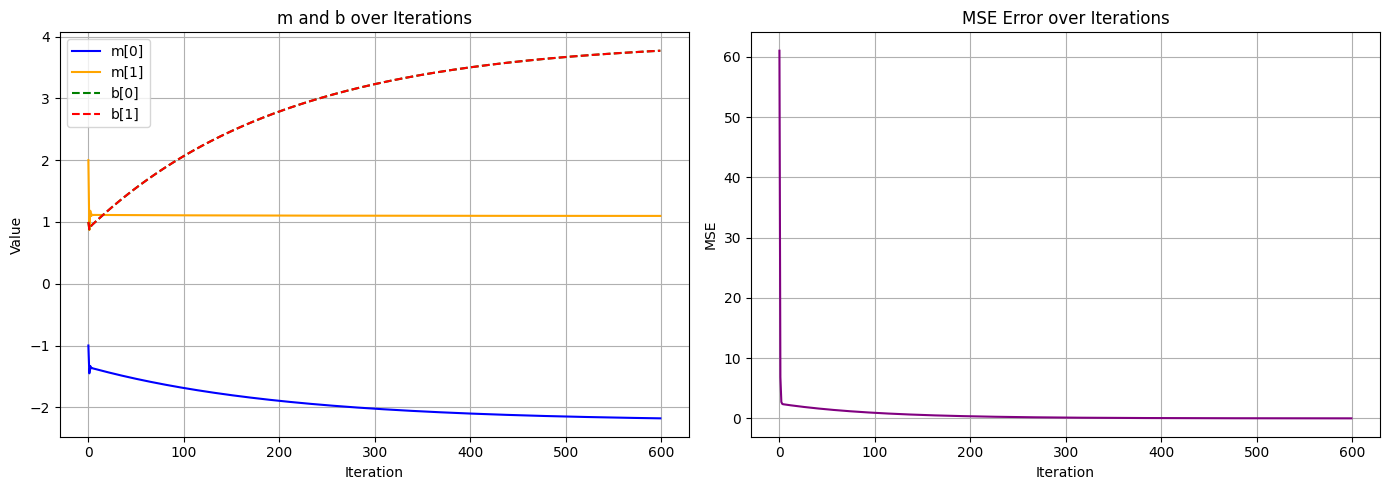

In [ ]:
m_history = np.array(m_history)
b_history = np.array(b_history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: m and b over iterations
axes[0].plot(m_history[:, 0], label='m[0]', color='blue')
axes[0].plot(m_history[:, 1], label='m[1]', color='orange')
axes[0].plot(b_history[:, 0], label='b[0]', color='green', linestyle='--')
axes[0].plot(b_history  [:, 1], label='b[1]', color='red', linestyle='--')
axes[0].set_title('m and b over Iterations')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Value')
axes[0].legend()
axes[0].grid(True)

# Plot 2: MSE over iterations
axes[1].plot(error_history, color='purple')
axes[1].set_title('MSE Error over Iterations')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('MSE')
axes[1].grid(True)

plt.tight_layout()
plt.show()